In [16]:
import seaborn as sns

### Loading Data

In [17]:
from datasets import load_dataset

dataset = load_dataset(
    "AliArshad/Bugzilla_Eclipse_Bug_Reports_Dataset"
)

df = dataset["train"].to_pandas()

print(df.columns)
print(df.shape)
print(df.head())

Repo card metadata block was not found. Setting CardData to empty.


Index(['Project', 'Bug ID', 'Severity Label', 'Resolution Status',
       'Short Description'],
      dtype='str')
(88682, 5)
    Project  Bug ID Severity Label Resolution Status  \
0  Bugzilla  322082         normal             FIXED   
1  Bugzilla  322412        trivial             FIXED   
2  Bugzilla  322315         normal             FIXED   
3  Bugzilla  322244        trivial             FIXED   
4  Bugzilla  322212       critical             FIXED   

                                   Short Description  
0                        Clean up user selection SQL  
1                              Typo in error message  
2  If logged out $user->can_bless gives: Not an A...  
3  cookies are incorrectly detainted when logging...  
4  DERIVE_GROUPS_TABLES_ALREADY_LOCKED is ignored...  


### EDA

Severity Label
normal      72170
critical     5936
major        4573
minor        3125
trivial      2080
blocker       798
Name: count, dtype: int64


<Axes: xlabel='Severity Label', ylabel='count'>

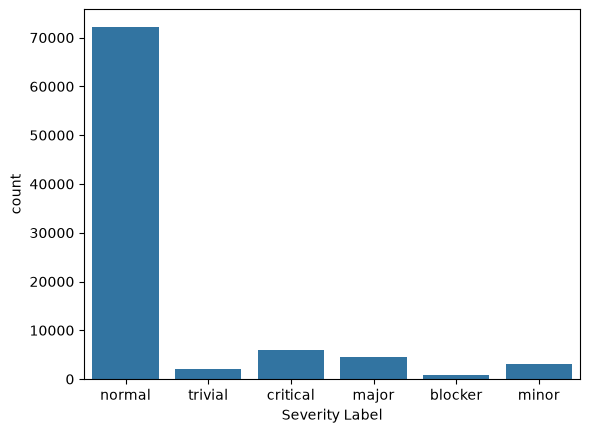

In [18]:
print(df['Severity Label'].value_counts())
sns.countplot(data = df, x='Severity Label') # Massive Class Imbalance

To solve class `Imbalance` Problem, we will remove normal:-

Keep:
- blocker
- critical
- major
- minor
- trivial

Reason:

- The project is called Bug Severity Predictor.
`normal` is often treated differently from actual severity levels and completely dominates the dataset.

In [19]:
df.isnull().sum()

Project              0
Bug ID               0
Severity Label       0
Resolution Status    0
Short Description    0
dtype: int64

In [20]:
df['Short Description'].str.len().describe()

count    88682.000000
mean        59.164566
std         24.576585
min          1.000000
25%         43.000000
50%         56.000000
75%         71.000000
max        255.000000
Name: Short Description, dtype: float64

In [21]:
df.dtypes

Project                str
Bug ID               int64
Severity Label         str
Resolution Status      str
Short Description      str
dtype: object

### Create New Dataset

In [22]:
severity_classes = [
    "blocker",
    "critical",
    "major",
    "minor",
    "trivial"
]

df_filtered = df[df["Severity Label"].isin(severity_classes)]
print(df_filtered.shape)
print(df_filtered["Severity Label"].value_counts())

(16512, 5)
Severity Label
critical    5936
major       4573
minor       3125
trivial     2080
blocker      798
Name: count, dtype: int64


### Select required Columns and Rename

In [23]:
df_filtered = df_filtered[ ["Short Description", "Severity Label"] ].copy()
df_filtered.columns = ["text", "severity"]
df_filtered.head()

,text,severity
1,Typo in error message,trivial
3,cookies are incorrectly detainted when logging...,trivial
4,DERIVE_GROUPS_TABLES_ALREADY_LOCKED is ignored...,critical
9,trivial UI changes for 2.20 (Selenium compat),trivial
13,admin/classifications/select.html.tmpl has a l...,trivial


### Save Dataset

In [26]:
df_filtered.to_csv( "../data/bug_reports_filtered.csv", index=False )
print("Dataset saved to 'data/bug_reports_filtered.csv' ")

Dataset saved to 'data/bug_reports_filtered.csv' 
